# Julia notebook to compute the buoyancy field using the 1D vertical diffusion equation, inspired by Peterson & Callies (2025, in review) theory.

twnh Sep '25

This notebook solves the steady vertical diffusion problem with a Green's function.

The problem is to solve:
\begin{align}
\frac{\partial }{\partial z} \left(\kappa(z)  \frac{db}{dz} \right)
    + \gamma \left( B(z) - b \right) & = 0 , \\
\frac{\partial }{\partial z} \left(\kappa_0 + \exp \left( - \alpha (z + H ) \right)  \frac{db}{dz} \right)
    + \gamma \left( B(z) - b \right) & = 0 , \\
\left[ \kappa_{0} + \exp \left( -\alpha(z + H) \right) \right] \frac{d^2 b}{dz^2}
    - \alpha \exp \left( -\alpha(z + H) \right) \frac{db}{dz}
    + \gamma \left( B(z) - b \right) & = 0 ,
\end{align}
for $b(z)$, given buoyancy profile $B(z)$, relaxation coefficient $\gamma$, with boundary conditions
\begin{align}
 \frac{db}{dz}  &= \beta \text{~ at~} z = -H , \\
 b &= 0 \text{~ at~} z = 0 ,
\end{align}
where bottom buoyancy gradient is $\beta$ (can be zero).
This is the canonical form of Zwillinger (1992), page 270, if $\beta = 0$.

This problem is solved repeatedly for different $H(x)$ fields and $B(x,z)$ fields. This constructs a buoyancy field that varies in $(x,z)$ using the 1D diffusion equation.

See also: ``DiffusionEquationSolution.ipynb`` for the G's function solution to the 1D buoyancy equation.

### Approach: Solve the Green's function problem first:

\begin{align}
0 & = \left[ \kappa_{0} + \exp \left( -\alpha(z + H) \right) \right] \frac{d^2 G}{dz^2}
    - \alpha \exp \left( -\alpha(z + H) \right) \frac{d G}{dz}
    - \gamma G + \delta(z - \xi) , \\
\implies 
0 & = \frac{d}{d z} \left( \kappa(z) \frac{d G}{dz} \right)
    - \gamma G + \delta(z - \xi) 
\end{align}
for $G(z; \xi)$ with boundary conditions
\begin{align}
 \left. \frac{dG}{dz} \right|_{z = -H} = 0 , \\
 G(0; \xi) = 0.
\end{align}

### Solution:

Construct $G(z; \xi)$ either side of the point $\xi$:

1. Solve for $G_- (z)$ on $-H \le z \le \xi$, such that

\begin{equation}
0 = \left[ \kappa_{0} + \exp \left( -\alpha(z + H) \right) \right] \frac{d^2 G_-}{dz^2}
    - \alpha \exp \left( -\alpha(z + H) \right) \frac{d G_-}{dz}
    - \gamma G_-  ,
\end{equation}

with boundary condition

\begin{equation}
 \left. \frac{dG_-}{dz} \right|_{z = -H} = 0 ,
\end{equation}

2. Solve for $G_+ (z)$ on $\xi \le z \le 0$, such that

\begin{equation}
0 = \left[ \kappa_{0} + \exp \left( -\alpha(z + H) \right) \right] \frac{d^2 G_+}{dz^2}
    - \alpha \exp \left( -\alpha(z + H) \right) \frac{d G_+}{dz}
    - \gamma G_+  ,
\end{equation}
with boundary condition

\begin{equation}
 G_+ (0) = 0 .
\end{equation}

3. Compute the Wronskian of $G_-(z)$ and $G_+(z)$:

\begin{equation}
W(z) = \left| 
\begin{matrix} 
G_-(z) & G_+ (z) \\
G_-'(z) & G_+' (z) 
\end{matrix} \right| .
\end{equation}

4. Write the Green's function as

\begin{align}
G(z; \xi) = \begin{cases}
\displaystyle \frac{G_-(z) G_+(\xi)}{ W(\xi)} &\text{\normalsize~~for~} -H \le z \le \xi \\
\displaystyle \frac{G_+(z) G_-(\xi)}{W(\xi)} &\text{\normalsize~~for~} \xi \le z \le 0 
\end{cases} .
\end{align}

This eliminates the unknown integration constants in $G_-$ and $G_+$.

5. Solve the original problem using $G(z; \xi)$:

\begin{equation}
b(z) = \gamma \int_{-H}^{0} G(z; \xi) B(\xi) \; d \xi + \beta G(z,-H) .
\end{equation}

In [1]:
using SymPy

Define symbols and functions

In [2]:
κ₀, α, H, γ = symbols("κ₀ α H γ", real=true, positive=true)
z, ξ        = symbols("z ξ A",    real=true, negative=true)
b           = SymFunction("b")
B           = SymFunction("B")
A, β        = symbols("A β",    real=true)
im          = SymPy.im  # SymPy's imaginary unit

# Define diffusivity profile here:
κ = κ₀                             # Constant viscosity profile
# κ = κ₀ + exp(-α*(z+H))               # Bottom-intensified viscosity profile. THIS DOESN"T WORK YET!  SymPy struggles to compute the integrals at the end.

# Define the $B(z)$ source term here:
B = z                                # Linear profile with vanishing surface buoyancy

β = 0          # Zero bottom buoyancy gradient. NON-ZERO β DOESN"T WORK YET!  I need to think about the math more carefully.

0

Define the ODE:

In [3]:
ode = Eq(κ * diff(diff(b(z),z),z) - diff(κ,z) * diff(b(z),z) - γ * b(z), 0)

              2           
             d            
-γ*b(z) + κ₀*---(b(z)) = 0
               2          
             dz           

1. Solve for $G_- (z)$ on $-H \le z \le \xi$,

In [4]:
bm = dsolve(ode, b(z), ics = Dict(diff(b(z),z).subs(z,-H)=>β)).rhs
@assert simplify(diff(bm,z).subs(z,-H) - β) == 0              # Check Neumann BC at bottom
bm_const = filter(x -> startswith(string(x), "C"), bm.free_symbols)
bm = bm.subs(first(bm_const), A)                              # Replace constant with A so it doesn't conflict later

       ___             ___        ___ 
   z*\/ γ       -2*H*\/ γ    -z*\/ γ  
   -------      -----------  ---------
     ____           ____        ____  
   \/ κ₀          \/ κ₀       \/ κ₀   
A*e        + A*e           *e         

2. Solve for $G_+(z)$ on  $\xi \le z \le 0$

In [5]:
bp = dsolve(ode, b(z), ics = Dict(b(0)=>0) ).rhs
@assert simplify(bp.subs(z,0)) == 0                         # Check Dirichlet BC at top
display(bp)

        ___            ___ 
    z*\/ γ        -z*\/ γ  
    -------       ---------
      ____           ____  
    \/ κ₀          \/ κ₀   
C2*e        - C2*e         

3. Compute Wronskian $W(z)$:

In [6]:
W = simplify(bm * diff(bp, z) - bp * diff(bm, z))

                                    ___ 
                             -2*H*\/ γ  
                             -----------
                                 ____   
         ___            ___    \/ κ₀    
2*A*C2*\/ γ    2*A*C2*\/ γ *e           
------------ + -------------------------
     ____                 ____          
   \/ κ₀                \/ κ₀           

4. Compute Green's function $G(z; \xi)$:

In [7]:
Gm = simplify(bm * bp.subs(z,ξ) / (κ.subs(z,ξ) * W.subs(z,ξ)))
Gp = simplify(bm.subs(z,ξ) * bp / (κ.subs(z,ξ) * W.subs(z,ξ)))

# Check continuity and jump condition:
@assert Gm.subs(z,ξ) - Gp.subs(z,ξ) == 0
@assert simplify(diff(Gm, z).subs(z,ξ) - diff(Gp, z).subs(z,ξ)) + 1/κ.subs(z,ξ) == 0

display(Gm)
display(Gp)

/          ___   \ /       ___           ___ \    ___        
|     -2*\/ γ *ξ | | 2*H*\/ γ     -2*z*\/ γ  |  \/ γ *(z + ξ)
|     -----------| | ---------    -----------|  -------------
|         ____   | |    ____          ____   |       ____    
|       \/ κ₀    | |  \/ κ₀         \/ κ₀    |     \/ κ₀     
\1 - e           /*\e          + e           /*e             
-------------------------------------------------------------
                              /       ___    \               
                              | 2*H*\/ γ     |               
                              | ---------    |               
                              |    ____      |               
                   ___   ____ |  \/ κ₀       |               
               2*\/ γ *\/ κ₀ *\e          + 1/               

/            ___ \ /       ___         ___   \    ___        
|     -2*z*\/ γ  | | 2*H*\/ γ     -2*\/ γ *ξ |  \/ γ *(z + ξ)
|     -----------| | ---------    -----------|  -------------
|         ____   | |    ____          ____   |       ____    
|       \/ κ₀    | |  \/ κ₀         \/ κ₀    |     \/ κ₀     
\1 - e           /*\e          + e           /*e             
-------------------------------------------------------------
                              /       ___    \               
                              | 2*H*\/ γ     |               
                              | ---------    |               
                              |    ____      |               
                   ___   ____ |  \/ κ₀       |               
               2*\/ γ *\/ κ₀ *\e          + 1/               

In [8]:
# Define piecewise Green's function:
G = simplify(sympy.Piecewise((Gm, Le(z,ξ)), (Gp, Ge(z,ξ))))

# Check boundary conditions are satisfied
@assert simplify(diff(G,z).subs(z,-H).subs(ξ,-H/3) - β) == 0
@assert simplify(G.subs(z,0).subs(ξ,-H/3)) == 0

display(G)

//          ___   \ /       ___           ___ \    ___                    
||     -2*\/ γ *ξ | | 2*H*\/ γ     -2*z*\/ γ  |  \/ γ *(z + ξ)            
||     -----------| | ---------    -----------|  -------------            
||         ____   | |    ____          ____   |       ____                
||       \/ κ₀    | |  \/ κ₀         \/ κ₀    |     \/ κ₀                 
|\1 - e           /*\e          + e           /*e                         
|-------------------------------------------------------------  for z <= ξ
|                              /       ___    \                           
|                              | 2*H*\/ γ     |                           
|                              | ---------    |                           
|                              |    ____      |                           
|                   ___   ____ |  \/ κ₀       |                           
|               2*\/ γ *\/ κ₀ *\e          + 1/                           
<                        

5. Solve the original problem using $G(z; \xi)$:

In [9]:
b = integrate(-G * γ * B.subs(z,ξ), (ξ,-H,0) )
display(simplify(b))

/                    ___                     ___                             _ >
|              2*z*\/ γ                  2*\/ γ *(H + z)                 2*\/  >
|              ---------                 ---------------                 ----- >
|                 ____                         ____                            >
|  ___   ____   \/ κ₀        ___   ____      \/ κ₀           ___   ____        >
|\/ γ *\/ κ₀ *e            \/ γ *\/ κ₀ *e                  \/ γ *\/ κ₀ *e      >
|----------------------- + ----------------------------- - ------------------- >
\           2                            2                                   2 >
------------------------------------------------------------------------------ >
                                                                               >
                                                                               >
                                                                               >
                            

### Plotting

Make plot of Green's function for sample parameters

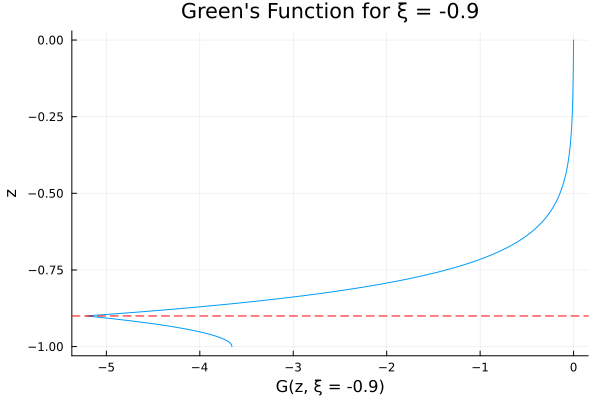

In [10]:
using Plots

# Pick the value of ξ in [-H, 0]:
ξᵢ     = -0.9
α_val  = 8.0
H_val  = 1.0
κ₀_val = 0.0125
γ_val  = 1.0

# Insert parameter values here and convert symbolic G to a function:
G_fixed(zᵢ,ξᵢ)  = G.subs([(κ₀, κ₀_val), (α, α_val), (γ, γ_val), (ξ, ξᵢ), (z, zᵢ)])

# --- Plot ---
zvals = range(-1, 0, length=512)
Gvals = [G_fixed(z_, ξᵢ).subs(H, H_val) |> float for z_ in zvals]  # use float() to get a number
plot(Gvals, zvals, ylabel="z", xlabel="G(z, ξ = $ξᵢ)", title="Green's Function for ξ = $ξᵢ", legend=false)
hline!([ξᵢ], label="ξ", linestyle=:dash, color=:red)

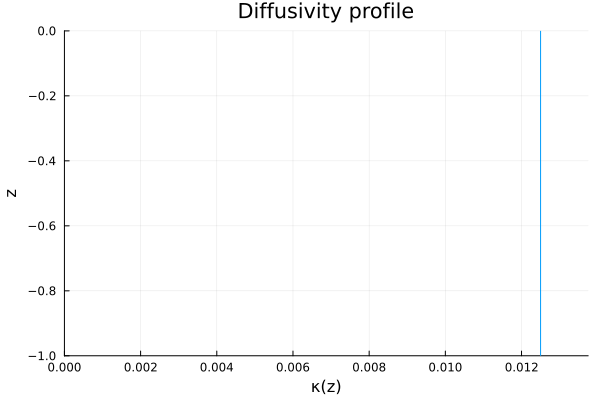

In [11]:
κ_fixed(zᵢ) = κ.subs([(κ₀, κ₀_val), (α, α_val), (H, H_val), (z, zᵢ)])
κvals = [κ_fixed(z_) |> float for z_ in zvals]
plot( κvals, zvals, label="κ(z)", ylabel="z", xlabel="κ(z)", title="Diffusivity profile", legend=false, xlims=(0,maximum(κvals) * 1.1), ylims=(-H_val,0) )

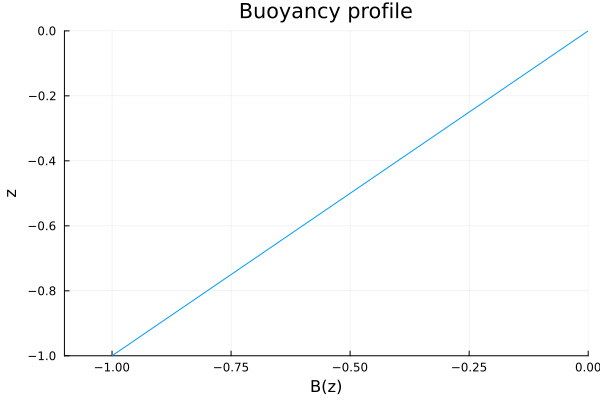

In [12]:
B_fixed(zᵢ) = B.subs([(z, zᵢ)])
Bvals = [B_fixed(z_) |> float for z_ in zvals]
plot( Bvals, zvals, label="B(z)", ylabel="z", xlabel="B(z)", title="Buoyancy profile", legend=false, xlims=(minimum(Bvals) * 1.1,maximum(Bvals) * 1.1), ylims=(-H_val,0) )

In [13]:
# this_b = simplify(b.subs([(κ₀, κ₀_val), (α, α_val), (H, H_val), (γ, γ_val)]))
# display(this_b) # Display symbolic b(z)
# @assert simplify(diff(this_b,z).subs(z,-H_val) - β) < 1e-10        # Check Neumann BC at bottom
# @assert simplify(this_b.subs(z,0)) < 1e-14                         # Check Dirichlet BC at top    

# b_fixed(zᵢ) = this_b.subs(z, zᵢ)
# bvals = [b_fixed(z_) |> float for z_ in zvals]
# plt = plot( bvals, zvals, label="b(z)", ylabel="z", xlabel="b(z)", title="Buoyancy profile", legend=true, xlims=(minimum(bvals),maximum(bvals) * 1.1), ylims=(-H_val,0) )

Loop over different depths to construct the buoyancy field $b(x,z)$

In [ ]:
aspect_ratio = 0.5  # Aspect ratio of the basin
xvals = range(-1, 1, length=256)
depth(x) = aspect_ratio * (1 - x^2)  # bathymetry
zvals = range(-depth(0), 0, length=256)
b_tmp = simplify(b.subs([(κ₀, κ₀_val), (α, α_val), (γ, γ_val)]))        # Temporary symbolic b(z) with parameters inserted, but H still symbolic
bz = fill(NaN, length(zvals), length(xvals))

for x ∈ xvals
    this_H = depth(x)
    this_b = b_tmp.subs(H, this_H)
    b_fixed(zᵢ) = this_b.subs(z, zᵢ)
    these_z_inds   = findall(zvals .>= -this_H)                         # Only plot down to the local depth
    these_z_vals   = zvals[these_z_inds]
    bvals = [b_fixed(z_) |> float for z_ in these_z_vals]
    # @info "For (x,H) = ($x, $this_H)"
    # @info bvals
    # @info "this_b = ", this_b
    @assert simplify(diff(this_b,z).subs(z,-this_H) - β) < 1e-12        # Check Neumann BC at bottom
    @assert simplify(this_b.subs(z,0)) < 1e-12                          # Check Dirichlet BC at top    
    bz[these_z_inds, findfirst(==(x), xvals)] = bvals                   # Store b(x,z)
end

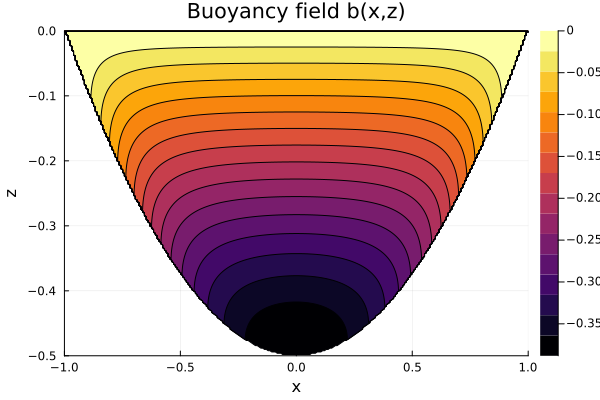

In [21]:
contour(xvals, zvals, bz, xlabel="x", ylabel="z", title="Buoyancy field b(x,z)", fill=true)
